In [ ]:
gfrom google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/Generalizable-DDA-RL

/content/drive/MyDrive/Generalizable-DDA-RL


### ***Imports***

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.environment import GADDAEnv

print("Imports Successful")

Imports Successful


In [ ]:
%%writefile src/baselines.py

import numpy as np


class StaticPolicy:
    """
    Always selects the same difficulty.
    """

    def __init__(self, difficulty):

        self.difficulty = float(
            np.clip(
                difficulty,
                0.0,
                1.0
            )
        )


    def reset(self):

        pass


    def select_action(
        self,
        observation
    ):

        return np.array(
            [self.difficulty],
            dtype=np.float32
        )


class RuleBasedDDA:
    """
    Simple rule-based Dynamic Difficulty Adjustment.

    If player performs above the target:
        increase difficulty.

    If player performs below the target:
        decrease difficulty.

    Otherwise:
        keep difficulty stable.
    """

    def __init__(
        self,
        target_win_rate=0.70,
        tolerance=0.05,
        adjustment_step=0.05,
        initial_difficulty=0.50
    ):

        self.target_win_rate = (
            target_win_rate
        )

        self.tolerance = tolerance

        self.adjustment_step = (
            adjustment_step
        )

        self.initial_difficulty = (
            initial_difficulty
        )

        self.reset()


    def reset(self):

        self.current_difficulty = (
            self.initial_difficulty
        )


    def select_action(
        self,
        observation
    ):

        recent_win_rate = float(
            observation[2]
        )


        upper_threshold = (
            self.target_win_rate
            +
            self.tolerance
        )


        lower_threshold = (
            self.target_win_rate
            -
            self.tolerance
        )


        if (
            recent_win_rate
            >
            upper_threshold
        ):

            self.current_difficulty += (
                self.adjustment_step
            )


        elif (
            recent_win_rate
            <
            lower_threshold
        ):

            self.current_difficulty -= (
                self.adjustment_step
            )


        self.current_difficulty = float(
            np.clip(
                self.current_difficulty,
                0.0,
                1.0
            )
        )


        return np.array(
            [
                self.current_difficulty
            ],
            dtype=np.float32
        )

Writing src/baselines.py


### ***One Reusable Evaluation Function***

In [ ]:
def run_episode(
    env,
    policy,
    seed=42
):

    observation, info = env.reset(
        seed=seed
    )

    policy.reset()


    terminated = False
    truncated = False


    episode_data = []

    total_reward = 0


    while not (
        terminated
        or
        truncated
    ):

        action = policy.select_action(
            observation
        )


        (
            observation,
            reward,
            terminated,
            truncated,
            info
        ) = env.step(
            action
        )


        total_reward += reward


        episode_data.append({

            "step":
                env.current_step,

            "difficulty":
                info["difficulty"],

            "true_skill":
                info["true_skill"],

            "estimated_skill":
                info["estimated_skill"],

            "uncertainty":
                info["uncertainty"],

            "success":
                info["success"],

            "recent_win_rate":
                info[
                    "recent_win_rate"
                ],

            "error_rate":
                info["error_rate"],

            "reward":
                reward
        })


    return (
        pd.DataFrame(
            episode_data
        ),
        total_reward
    )

### ***Standard Player Test***

In [ ]:
player_config = {

    "initial_skill":
        0.5,

    "learning_rate":
        0.0,

    "fatigue_rate":
        0.0,

    "noise_std":
        0.05
}

In [ ]:
env = GADDAEnv(

    max_steps=200,

    target_win_rate=0.70,

    player_config=player_config,

    seed=42
)


print("Environment is Ready")

Environment is Ready


In [ ]:
from src.baselines import (
    StaticPolicy,
    RuleBasedDDA
)


easy_policy = StaticPolicy(
    difficulty=0.30
)

medium_policy = StaticPolicy(
    difficulty=0.50
)

hard_policy = StaticPolicy(
    difficulty=0.70
)


rule_policy = RuleBasedDDA(
    target_win_rate=0.70
)


print("Baselines Created Successfully!")

Baselines Created Successfully!


### ***Static Easy***

In [ ]:
easy_data, easy_reward = run_episode(

    env,

    easy_policy,

    seed=42
)


print(
    "Static Easy Total Reward:",
    round(
        easy_reward,
        3
    )
)


easy_data.head()

Static Easy Total Reward: 213.26


,step,difficulty,true_skill,estimated_skill,uncertainty,success,recent_win_rate,error_rate,reward
0,1,0.3,0.5,0.577778,0.200000,1,1.000000,0.0,0.880000
1,2,0.3,0.5,0.640000,0.021999,1,1.000000,0.0,0.897800
2,3,0.3,0.5,0.587061,0.020000,0,0.666667,0.0,1.164667
3,4,0.3,0.5,0.647427,0.020000,1,0.750000,0.0,1.148000
4,5,0.3,0.5,0.695693,0.020000,1,0.800000,0.0,1.098000


### ***Static Medium***

In [ ]:
medium_data, medium_reward = run_episode(

    env,

    medium_policy,

    seed=42
)


print(
    "Static Medium Total Reward:",
    round(
        medium_reward,
        3
    )
)


medium_data.head()

Static Medium Total Reward: 196.136


,step,difficulty,true_skill,estimated_skill,uncertainty,success,recent_win_rate,error_rate,reward
0,1,0.5,0.5,0.575000,0.200000,1,1.000000,3.122502e-17,0.880000
1,2,0.5,0.5,0.535000,0.020000,0,0.500000,4.857226e-17,0.998000
2,3,0.5,0.5,0.491023,0.020000,0,0.333333,1.951035e-01,0.792313
3,4,0.5,0.5,0.467818,0.020587,0,0.250000,4.336809e-18,0.747941
4,5,0.5,0.5,0.549150,0.020000,1,0.400000,1.680116e-03,0.897664


### ***Static Hard***

In [ ]:
hard_data, hard_reward = run_episode(

    env,

    hard_policy,

    seed=42
)


print(
    "Static Hard Total Reward:",
    round(
        hard_reward,
        3
    )
)


hard_data.head()

Static Hard Total Reward: 127.037


,step,difficulty,true_skill,estimated_skill,uncertainty,success,recent_win_rate,error_rate,reward
0,1,0.7,0.5,0.462727,0.20,0,0.0,0.200000,0.440000
1,2,0.7,0.5,0.432909,0.02,0,0.0,0.200000,0.458000
2,3,0.7,0.5,0.397448,0.02,0,0.0,0.395104,0.418979
3,4,0.7,0.5,0.380686,0.02,0,0.0,0.200000,0.458000
4,5,0.7,0.5,0.367174,0.02,0,0.0,0.201680,0.457664


### ***Rule Based DDA***

In [ ]:
rule_data, rule_reward = run_episode(

    env,

    rule_policy,

    seed=42
)


print(
    "Rule-Based DDA Total Reward :",
    round(
        rule_reward,
        3
    )
)


rule_data.head()

Rule-Based DDA Total Reward : 207.706


,step,difficulty,true_skill,estimated_skill,uncertainty,success,recent_win_rate,error_rate,reward
0,1,0.45,0.5,0.575641,0.20,1,1.000000,0.000000e+00,0.880000
1,2,0.50,0.5,0.535513,0.02,0,0.500000,4.857226e-17,0.993000
2,3,0.45,0.5,0.494464,0.02,0,0.333333,1.451035e-01,0.797313
3,4,0.40,0.5,0.471887,0.02,0,0.250000,0.000000e+00,0.743000
4,5,0.35,0.5,0.554512,0.02,1,0.400000,0.000000e+00,0.893000


### ***Comparing Win Rates***

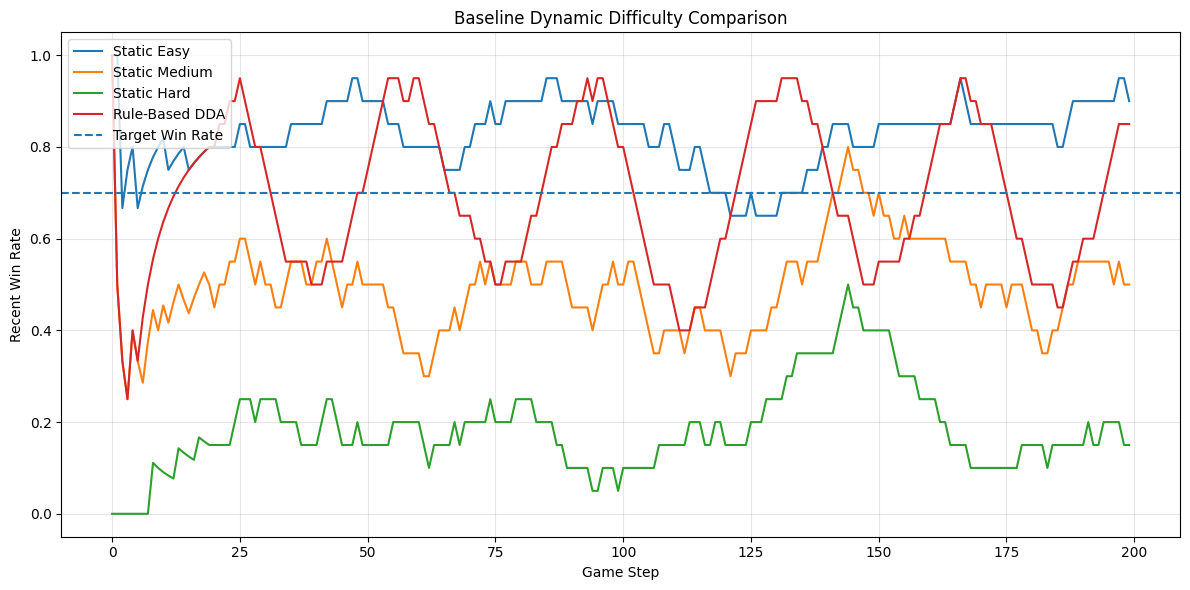

In [ ]:
plt.figure(figsize=(12, 6))


plt.plot(
    easy_data["recent_win_rate"],
    label="Static Easy"
)

plt.plot(
    medium_data["recent_win_rate"],
    label="Static Medium"
)

plt.plot(
    hard_data["recent_win_rate"],
    label="Static Hard"
)

plt.plot(
    rule_data["recent_win_rate"],
    label="Rule-Based DDA"
)


plt.axhline(
    0.70,
    linestyle="--",
    label="Target Win Rate"
)


plt.xlabel(
    "Game Step"
)

plt.ylabel(
    "Recent Win Rate"
)

plt.title(
    "Baseline Dynamic Difficulty Comparison"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

### ***Baseline Metrics***

In [ ]:
def calculate_metrics(
    data,
    target_win_rate=0.70
):

    win_rate_error = np.mean(

        np.abs(

            data[
                "recent_win_rate"
            ]

            -

            target_win_rate

        )

    )


    difficulty_smoothness = np.std(

        np.diff(

            data[
                "difficulty"
            ]

        )

    )


    mean_episode_length = len(
        data
    )


    mean_error_rate = np.mean(

        data[
            "error_rate"
        ]

    )


    return {

        "Win Rate Error":
            win_rate_error,

        "Difficulty Change Std":
            difficulty_smoothness,

        "Episode Length":
            mean_episode_length,

        "Mean Error Rate":
            mean_error_rate
    }

In [ ]:
baseline_results = pd.DataFrame({

    "Static Easy":
        calculate_metrics(
            easy_data
        ),

    "Static Medium":
        calculate_metrics(
            medium_data
        ),

    "Static Hard":
        calculate_metrics(
            hard_data
        ),

    "Rule-Based DDA":
        calculate_metrics(
            rule_data
        )
}).T


baseline_results

,Win Rate Error,Difficulty Change Std,Episode Length,Mean Error Rate
Static Easy,0.131569,0.000000,200.0,0.000198
Static Medium,0.209972,0.000000,200.0,0.036269
Static Hard,0.515472,0.000000,200.0,0.236269
Rule-Based DDA,0.144417,0.044527,200.0,0.051314


In [ ]:
baseline_results.to_csv(

    "results/tables/"
    "baseline_results.csv"
)


print(
    "Baseline Results Saved!"
)

Baseline Results Saved!


In [ ]:
!find src results -type f | sort

results/figures/player_profiles.png
results/figures/skill_estimation_with_uncertainty.png
results/figures/true_vs_estimated_skill.png
results/tables/baseline_results.csv
src/baselines.py
src/environment.py
src/__init__.py
src/player_estimator.py
src/player.py
src/__pycache__/baselines.cpython-313.pyc
src/__pycache__/environment.cpython-313.pyc
src/__pycache__/__init__.cpython-313.pyc
src/__pycache__/player.cpython-313.pyc
src/__pycache__/player_estimator.cpython-313.pyc
